# Augmented Training — Baseline CNN with Generated Data
### Compare: Baseline vs. +cVAE vs. +GAN vs. +WGAN-GP vs. +BigGAN vs. +Diffusion

**Constraint from the enunciado (strictly enforced here):**
> *"You should only change the dataset and train the baseline model as in the script
> provided with the augmented dataset."*

- The `BaselineCNN` architecture is copied **exactly** from `TP2-students.ipynb` without any change.
- The training strategy (optimiser, loss, epochs, early stopping) is defined **once** and
  applied identically to all six runs.
- All six runs use the **same held-out test split** (produced by `get_splits(seed=42)`).


In [48]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import ConcatDataset
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# ── Device setup (following exemplos_modelos pattern) ──────────────────────
device = torch.device(
    "cuda"  if torch.cuda.is_available()  else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [49]:
sys.path.insert(0, os.path.abspath(".."))

from src.dataset import (
    ButterflyDataset, AugmentedButterflyDataset,
    get_splits, build_label_map,
    get_train_transform, get_baseline_transform, get_eval_transform, make_dataloader,
)
from src.utils import (
    save_checkpoint, load_checkpoint,
    plot_losses, EarlyStopping,
)
from src.metrics import classification_report_dict

In [50]:
# ── Paths ─────────────────────────────────────────────────────────────────
BASE_DIR  = os.path.abspath("..")
IMG_DIR   = os.path.join(BASE_DIR, "aca-butterflies", "train")
CSV_PATH  = os.path.join(BASE_DIR, "aca-butterflies", "train.csv")

def get_filtered_csv(model_name):
    """Returns the path to the filtered CSV, fallback to original if filtered doesn't exist."""
    filtered = os.path.join(BASE_DIR, "data", "generated", model_name, "filtered_generated.csv")
    original = os.path.join(BASE_DIR, "data", "generated", model_name, "generated.csv")
    if os.path.exists(filtered):
        print(f"Using FILTERED dataset for {model_name}")
        return filtered
    print(f"Warning: Filtered dataset not found for {model_name}, falling back to original.")
    return original

CVAE_CSV      = get_filtered_csv("cvae")
GAN_CSV       = get_filtered_csv("gan")
WGAN_GP_CSV   = get_filtered_csv("wgan_gp")
BIGGAN_CSV    = get_filtered_csv("biggan")
DIFFUSION_CSV = get_filtered_csv("diffusion")
AUG_DIR       = os.path.join(BASE_DIR, "data", "augmented")
os.makedirs(AUG_DIR, exist_ok=True)

# ── Training hyperparameters (IDENTICAL for all six runs) ────────────────
IMAGE_SIZE   = 64      # from TP2-students.ipynb
BATCH_SIZE   = 64      # RTX 5060 Laptop 8.5 GB VRAM
LR           = 0.001   # from TP2-students.ipynb: optim.Adam(model.parameters(), lr=0.001)
NUM_EPOCHS   = 100     # applied equally to baseline and augmented runs
ES_PATIENCE  = 15      # early stopping patience (same for all runs)
LR_PATIENCE  = 7       # ReduceLROnPlateau patience
LR_FACTOR    = 0.5     # halve LR on plateau
LR_MIN       = 1e-5    # LR floor

Using FILTERED dataset for cvae
Using FILTERED dataset for gan
Using FILTERED dataset for wgan_gp
Using FILTERED dataset for biggan
Using FILTERED dataset for diffusion


In [51]:
label_to_idx, idx_to_label = build_label_map(CSV_PATH)
num_classes = len(label_to_idx)
print(f"Number of classes: {num_classes}")

# Stratified split — same seed as generative notebooks → same test set
train_df, val_df, test_df = get_splits(CSV_PATH, train_ratio=0.70, val_ratio=0.15, seed=42)
print(f"Original — Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

Number of classes: 75
Original — Train: 3,606  Val: 745  Test: 848


## BaselineCNN
Copied **verbatim** from `TP2-students.ipynb` — no modifications allowed.


In [52]:
class BaselineCNN(nn.Module):
    """
    Baseline CNN — copied exactly from TP2-students.ipynb.
    DO NOT modify architecture, optimizer, or loss function.
    """

    def __init__(self, num_classes=75):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                        # 64×64 → 32×32
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                        # 32×32 → 16×16
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                        # 16×16 → 8×8
            nn.AdaptiveAvgPool2d((1, 1)),              # → 1×1
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)



In [53]:
def train_classifier(model, train_loader, val_loader,
                     num_epochs=NUM_EPOCHS, lr=LR,
                     es_patience=ES_PATIENCE, device=device,
                     save_path=None, run_name=""):
    """
    Identical training strategy for all three runs.
    Optimizer and loss match TP2-students.ipynb exactly:
      optimizer = optim.Adam(model.parameters(), lr=0.001)
      criterion = nn.CrossEntropyLoss()
    Returns (model, train_losses, val_losses, val_accs).
    """
    # Exactly as in TP2-students.ipynb
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=LR_PATIENCE,
        factor=LR_FACTOR, min_lr=LR_MIN,
    )
    es = EarlyStopping(patience=es_patience, mode="max")

    model = model.to(device)   # move model to GPU
    train_losses, val_losses, val_accs = [], [], []
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # ── Train ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device)      # move batch to GPU
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train = running_loss / len(train_loader)
        train_losses.append(avg_train)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        avg_val  = val_loss / len(val_loader)
        acc      = correct / total
        val_losses.append(avg_val)
        val_accs.append(acc)

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"[{run_name}] Epoch: {epoch+1:3d}  "
              f"Train Loss: {avg_train:.4f}  Val Loss: {avg_val:.4f}  Val Acc: {acc:.4f}  LR: {current_lr:.2e}")

        if acc > best_val_acc and save_path:
            best_val_acc = acc
            save_checkpoint(model, save_path, epoch=epoch+1, val_acc=acc)

        scheduler.step(acc)

        if es(acc):
            print(f"Early stopping at epoch {epoch+1}")
            break

    return model.to("cpu"), train_losses, val_losses, val_accs



In [54]:
def evaluate_classifier(model, test_loader, label_to_idx, idx_to_label, device=device):
    """Evaluate on held-out test split. Returns metrics dict."""
    model = model.to(device)
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_true.extend(labels.tolist())
    return classification_report_dict(all_true, all_preds, idx_to_label)



In [55]:
# ── Dataset Utilities ──────────────────────────────────────────────────────
def create_balanced_augmented_df(orig_df, gen_df, target_per_class=None):
    """
    Creates a balanced dataframe by adding generated images to original images.
    If target_per_class is None, it targets the size of the largest class in orig_df.
    """
    if target_per_class is None:
        target_per_class = orig_df["label"].value_counts().max()
    
    balanced_rows = [orig_df]
    
    for label, group in orig_df.groupby("label"):
        num_orig = len(group)
        num_needed = target_per_class - num_orig
        
        if num_needed > 0:
            gen_candidates = gen_df[gen_df["label"] == label]
            if len(gen_candidates) > 0:
                # Add up to num_needed or all available generated images
                num_to_add = min(num_needed, len(gen_candidates))
                balanced_rows.append(gen_candidates.sample(n=num_to_add, random_state=42))
                
    return pd.concat(balanced_rows, ignore_index=True)

# ── Shared test loader (identical across all runs) ────────────────────────
test_set    = ButterflyDataset(test_df, IMG_DIR, label_to_idx,
                                transform=get_eval_transform(IMAGE_SIZE))
test_loader = make_dataloader(test_set, BATCH_SIZE, shuffle=False)
print(f"Test samples: {len(test_set):,}")

Test samples: 848


## Run 1 — Baseline (original data only)

In [56]:
# Using get_train_transform instead of get_baseline_transform to improve generalization
baseline_train_set = ButterflyDataset(train_df, IMG_DIR, label_to_idx,
                                       transform=get_train_transform(IMAGE_SIZE))
baseline_val_set   = ButterflyDataset(val_df,   IMG_DIR, label_to_idx,
                                       transform=get_eval_transform(IMAGE_SIZE))

baseline_train_loader = make_dataloader(baseline_train_set, BATCH_SIZE, shuffle=True)
baseline_val_loader   = make_dataloader(baseline_val_set,   BATCH_SIZE, shuffle=False)

print(f"Baseline — Train: {len(baseline_train_set):,}  Val: {len(baseline_val_set):,}")

Baseline — Train: 3,606  Val: 745


[BASELINE] Epoch:   1  Train Loss: 4.2480  Val Loss: 4.0438  Val Acc: 0.0322  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   2  Train Loss: 4.0074  Val Loss: 3.7600  Val Acc: 0.0671  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   3  Train Loss: 3.8052  Val Loss: 3.7793  Val Acc: 0.0752  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   4  Train Loss: 3.5884  Val Loss: 3.3590  Val Acc: 0.0872  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   5  Train Loss: 3.4702  Val Loss: 3.3378  Val Acc: 0.0993  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
[BASELINE] Epoch:   6  Train Loss: 3.3255  Val Loss: 3.2517  Val Acc: 0.1060  LR: 1.00e-03
[checkpoint] saved → c:\Users

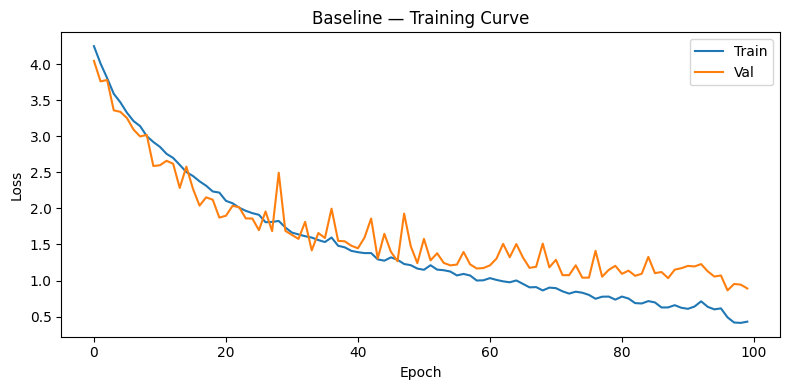

In [57]:
baseline_model = BaselineCNN(num_classes=num_classes)

baseline_model, bl_train_l, bl_val_l, bl_val_acc = train_classifier(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    run_name="BASELINE",
    save_path=os.path.join(BASE_DIR, "saved_models", "baseline.pth"),
)

plot_losses(bl_train_l, bl_val_l, title="Baseline — Training Curve")

In [58]:
load_checkpoint(os.path.join(BASE_DIR, "saved_models", "baseline.pth"), baseline_model)
baseline_metrics = evaluate_classifier(baseline_model, test_loader, label_to_idx, idx_to_label)
print(f"Baseline  |  Accuracy: {baseline_metrics['accuracy']:.4f}"
      f"  Macro F1: {baseline_metrics['macro_f1']:.4f}")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline.pth
Baseline  |  Accuracy: 0.7594  Macro F1: 0.7578


## Run 2 — Baseline + cVAE-Generated Data

In [59]:
cvae_gen_df = pd.read_csv(CVAE_CSV)
print(f"cVAE generated samples: {len(cvae_gen_df):,}")

# Build balanced augmented train set
combined_cvae_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), cvae_gen_df)
combined_cvae_df.to_csv(os.path.join(AUG_DIR, "cvae_augmented.csv"), index=False)
print(f"Combined balanced (original + cVAE): {len(combined_cvae_df):,}")

cvae_aug_train = AugmentedButterflyDataset(combined_cvae_df, label_to_idx,
                                            transform=get_train_transform(IMAGE_SIZE))
cvae_aug_val   = ButterflyDataset(val_df, IMG_DIR, label_to_idx,
                                   transform=get_eval_transform(IMAGE_SIZE))

cvae_train_loader = make_dataloader(cvae_aug_train, BATCH_SIZE, shuffle=True)
cvae_val_loader   = make_dataloader(cvae_aug_val,   BATCH_SIZE, shuffle=False)
print(f"Augmented train batches: {len(cvae_train_loader)}")

cVAE generated samples: 7
Combined balanced (original + cVAE): 3,613
Augmented train batches: 57


[+cVAE] Epoch:   1  Train Loss: 4.2319  Val Loss: 4.1828  Val Acc: 0.0295  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   2  Train Loss: 4.0237  Val Loss: 3.8289  Val Acc: 0.0497  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   3  Train Loss: 3.8942  Val Loss: 3.8675  Val Acc: 0.0456  LR: 1.00e-03
[+cVAE] Epoch:   4  Train Loss: 3.7744  Val Loss: 3.7341  Val Acc: 0.0523  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   5  Train Loss: 3.5698  Val Loss: 3.7388  Val Acc: 0.0886  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   6  Train Loss: 3.4510  Val Loss: 3.4192  Val Acc: 0.1007  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
[+cVAE] Epoch:   7  Tr

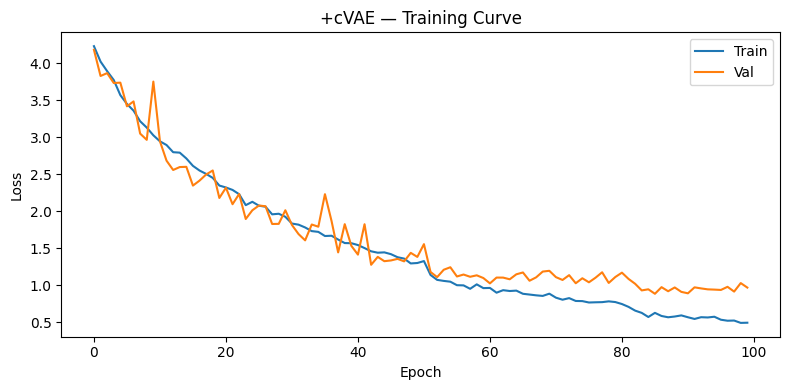

In [60]:
cvae_model = BaselineCNN(num_classes=num_classes)

cvae_model, cv_train_l, cv_val_l, cv_val_acc = train_classifier(
    cvae_model,
    cvae_train_loader,
    cvae_val_loader,
    run_name="+cVAE",
    save_path=os.path.join(BASE_DIR, "saved_models", "baseline_cvae.pth"),
)

plot_losses(cv_train_l, cv_val_l, title="+cVAE — Training Curve")

In [61]:
load_checkpoint(os.path.join(BASE_DIR, "saved_models", "baseline_cvae.pth"), cvae_model)
cvae_metrics = evaluate_classifier(cvae_model, test_loader, label_to_idx, idx_to_label)
print(f"+cVAE     |  Accuracy: {cvae_metrics['accuracy']:.4f}"
      f"  Macro F1: {cvae_metrics['macro_f1']:.4f}")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_cvae.pth
+cVAE     |  Accuracy: 0.7535  Macro F1: 0.7518


## Run 3 — Baseline + GAN-Generated Data

In [62]:
gan_gen_df = pd.read_csv(GAN_CSV)
print(f"GAN generated samples: {len(gan_gen_df):,}")

# Build balanced augmented train set
combined_gan_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), gan_gen_df)
combined_gan_df.to_csv(os.path.join(AUG_DIR, "gan_augmented.csv"), index=False)
print(f"Combined balanced (original + GAN): {len(combined_gan_df):,}")

gan_aug_train = AugmentedButterflyDataset(combined_gan_df, label_to_idx,
                                           transform=get_train_transform(IMAGE_SIZE))
gan_aug_val   = ButterflyDataset(val_df, IMG_DIR, label_to_idx,
                                  transform=get_eval_transform(IMAGE_SIZE))

gan_train_loader = make_dataloader(gan_aug_train, BATCH_SIZE, shuffle=True)
gan_val_loader   = make_dataloader(gan_aug_val,   BATCH_SIZE, shuffle=False)
print(f"Augmented train batches: {len(gan_train_loader)}")

GAN generated samples: 94
Combined balanced (original + GAN): 3,700
Augmented train batches: 58


[+GAN] Epoch:   1  Train Loss: 4.2566  Val Loss: 4.1209  Val Acc: 0.0376  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   2  Train Loss: 4.0629  Val Loss: 3.9497  Val Acc: 0.0510  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   3  Train Loss: 3.9121  Val Loss: 3.7225  Val Acc: 0.0698  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   4  Train Loss: 3.7062  Val Loss: 3.5162  Val Acc: 0.0966  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   5  Train Loss: 3.5704  Val Loss: 3.3493  Val Acc: 0.1329  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
[+GAN] Epoch:   6  Train Loss: 3.4053  Val Loss: 3.1543  Val Acc: 0.1409  LR: 1.00e-03
[checkpoint] saved → c:\Users\ric

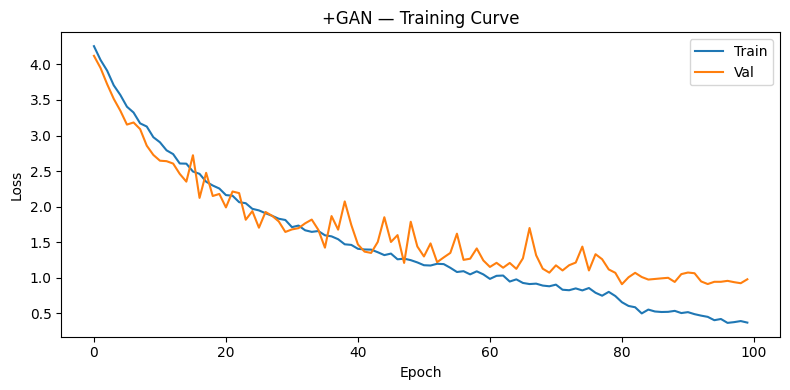

In [63]:
gan_model = BaselineCNN(num_classes=num_classes)

gan_model, gn_train_l, gn_val_l, gn_val_acc = train_classifier(
    gan_model,
    gan_train_loader,
    gan_val_loader,
    run_name="+GAN",
    save_path=os.path.join(BASE_DIR, "saved_models", "baseline_gan.pth"),
)

plot_losses(gn_train_l, gn_val_l, title="+GAN — Training Curve")

In [64]:
load_checkpoint(os.path.join(BASE_DIR, "saved_models", "baseline_gan.pth"), gan_model)
gan_metrics = evaluate_classifier(gan_model, test_loader, label_to_idx, idx_to_label)
print(f"+GAN      |  Accuracy: {gan_metrics['accuracy']:.4f}"
      f"  Macro F1: {gan_metrics['macro_f1']:.4f}")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_gan.pth
+GAN      |  Accuracy: 0.7677  Macro F1: 0.7684


## Run 4 — Baseline + WGAN-GP-Generated Data

In [65]:
wgan_gp_gen_df = pd.read_csv(WGAN_GP_CSV)
print(f"WGAN-GP generated samples: {len(wgan_gp_gen_df):,}")

# Build balanced augmented train set
combined_wgan_gp_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), wgan_gp_gen_df)
combined_wgan_gp_df.to_csv(os.path.join(AUG_DIR, "wgan_gp_augmented.csv"), index=False)
print(f"Combined balanced (original + WGAN-GP): {len(combined_wgan_gp_df):,}")

wgan_gp_aug_train = AugmentedButterflyDataset(combined_wgan_gp_df, label_to_idx,
                                               transform=get_train_transform(IMAGE_SIZE))
wgan_gp_aug_val   = ButterflyDataset(val_df, IMG_DIR, label_to_idx,
                                      transform=get_eval_transform(IMAGE_SIZE))

wgan_gp_train_loader = make_dataloader(wgan_gp_aug_train, BATCH_SIZE, shuffle=True)
wgan_gp_val_loader   = make_dataloader(wgan_gp_aug_val,   BATCH_SIZE, shuffle=False)
print(f"Augmented train batches: {len(wgan_gp_train_loader)}")

WGAN-GP generated samples: 61
Combined balanced (original + WGAN-GP): 3,667
Augmented train batches: 58


[+WGAN-GP] Epoch:   1  Train Loss: 4.2276  Val Loss: 4.0121  Val Acc: 0.0443  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_wgan_gp.pth
[+WGAN-GP] Epoch:   2  Train Loss: 3.9433  Val Loss: 3.8990  Val Acc: 0.0336  LR: 1.00e-03
[+WGAN-GP] Epoch:   3  Train Loss: 3.7280  Val Loss: 3.6693  Val Acc: 0.0953  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_wgan_gp.pth
[+WGAN-GP] Epoch:   4  Train Loss: 3.5701  Val Loss: 3.2155  Val Acc: 0.1356  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_wgan_gp.pth
[+WGAN-GP] Epoch:   5  Train Loss: 3.3900  Val Loss: 3.2995  Val Acc: 0.1181  LR: 1.00e-03
[+WGAN-GP] Epoch:   6  Train Loss: 3.3203  Val Loss: 3.0897  Val Acc: 0.1544  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_wgan_gp.pth
[+WGAN-GP] Epoch:   7  Train Loss: 3.1588  Val Loss: 3.6325  Val Acc: 0.0980  LR: 

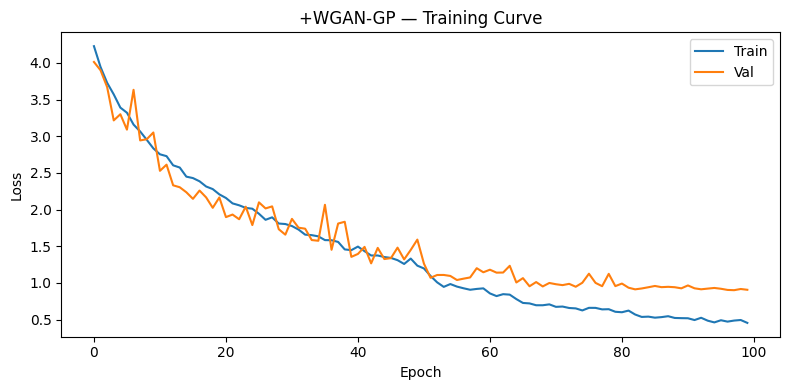

In [66]:
wgan_gp_model = BaselineCNN(num_classes=num_classes)

wgan_gp_model, wg_train_l, wg_val_l, wg_val_acc = train_classifier(
    wgan_gp_model,
    wgan_gp_train_loader,
    wgan_gp_val_loader,
    run_name="+WGAN-GP",
    save_path=os.path.join(BASE_DIR, "saved_models", "baseline_wgan_gp.pth"),
)

plot_losses(wg_train_l, wg_val_l, title="+WGAN-GP — Training Curve")

In [67]:
load_checkpoint(os.path.join(BASE_DIR, "saved_models", "baseline_wgan_gp.pth"), wgan_gp_model)
wgan_gp_metrics = evaluate_classifier(wgan_gp_model, test_loader, label_to_idx, idx_to_label)
print(f"+WGAN-GP  |  Accuracy: {wgan_gp_metrics['accuracy']:.4f}"
      f"  Macro F1: {wgan_gp_metrics['macro_f1']:.4f}")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_wgan_gp.pth
+WGAN-GP  |  Accuracy: 0.7606  Macro F1: 0.7567


## Run 5 — Baseline + BigGAN-Generated Data

In [68]:
biggan_gen_df = pd.read_csv(BIGGAN_CSV)
print(f"BigGAN generated samples: {len(biggan_gen_df):,}")

# Build balanced augmented train set
combined_biggan_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), biggan_gen_df)
combined_biggan_df.to_csv(os.path.join(AUG_DIR, "biggan_augmented.csv"), index=False)
print(f"Combined balanced (original + BigGAN): {len(combined_biggan_df):,}")

biggan_aug_train = AugmentedButterflyDataset(combined_biggan_df, label_to_idx,
                                              transform=get_train_transform(IMAGE_SIZE))
biggan_aug_val   = ButterflyDataset(val_df, IMG_DIR, label_to_idx,
                                    transform=get_eval_transform(IMAGE_SIZE))

biggan_train_loader = make_dataloader(biggan_aug_train, BATCH_SIZE, shuffle=True)
biggan_val_loader   = make_dataloader(biggan_aug_val,   BATCH_SIZE, shuffle=False)
print(f"Augmented train batches: {len(biggan_train_loader)}")

BigGAN generated samples: 119
Combined balanced (original + BigGAN): 3,725
Augmented train batches: 59


[+BigGAN] Epoch:   1  Train Loss: 4.2555  Val Loss: 4.0546  Val Acc: 0.0430  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_biggan.pth
[+BigGAN] Epoch:   2  Train Loss: 3.9468  Val Loss: 3.9330  Val Acc: 0.0537  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_biggan.pth
[+BigGAN] Epoch:   3  Train Loss: 3.7502  Val Loss: 3.5128  Val Acc: 0.0779  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_biggan.pth
[+BigGAN] Epoch:   4  Train Loss: 3.5992  Val Loss: 3.3352  Val Acc: 0.1114  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_biggan.pth
[+BigGAN] Epoch:   5  Train Loss: 3.5095  Val Loss: 3.4288  Val Acc: 0.1248  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_biggan.pth
[+BigGAN] Epoch:   6  Train Loss: 3.4357  Val Loss: 3.3372  Val Acc: 0.1168  LR: 1.00e-03


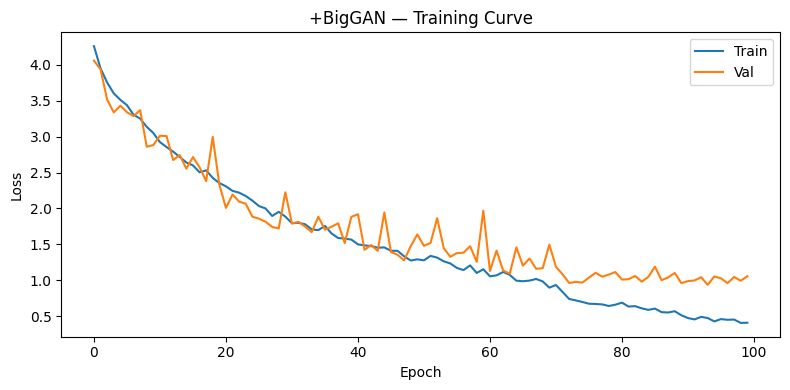

In [69]:
biggan_model = BaselineCNN(num_classes=num_classes)

biggan_model, bg_train_l, bg_val_l, bg_val_acc = train_classifier(
    biggan_model,
    biggan_train_loader,
    biggan_val_loader,
    run_name="+BigGAN",
    save_path=os.path.join(BASE_DIR, "saved_models", "baseline_biggan.pth"),
)

plot_losses(bg_train_l, bg_val_l, title="+BigGAN — Training Curve")

In [70]:
load_checkpoint(os.path.join(BASE_DIR, "saved_models", "baseline_biggan.pth"), biggan_model)
biggan_metrics = evaluate_classifier(biggan_model, test_loader, label_to_idx, idx_to_label)
print(f"+BigGAN   |  Accuracy: {biggan_metrics['accuracy']:.4f}"
      f"  Macro F1: {biggan_metrics['macro_f1']:.4f}")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_biggan.pth
+BigGAN   |  Accuracy: 0.7465  Macro F1: 0.7425


## Run 6 — Baseline + Diffusion-Generated Data

In [71]:
diff_gen_df = pd.read_csv(DIFFUSION_CSV)
print(f"Diffusion generated samples: {len(diff_gen_df):,}")

# Build balanced augmented train set
combined_diff_df = create_balanced_augmented_df(train_df.copy().assign(img_dir=IMG_DIR), diff_gen_df)
combined_diff_df.to_csv(os.path.join(AUG_DIR, "diffusion_augmented.csv"), index=False)
print(f"Combined balanced (original + Diffusion): {len(combined_diff_df):,}")

diff_aug_train = AugmentedButterflyDataset(combined_diff_df, label_to_idx,
                                            transform=get_train_transform(IMAGE_SIZE))
diff_aug_val   = ButterflyDataset(val_df, IMG_DIR, label_to_idx,
                                   transform=get_eval_transform(IMAGE_SIZE))

diff_train_loader = make_dataloader(diff_aug_train, BATCH_SIZE, shuffle=True)
diff_val_loader   = make_dataloader(diff_aug_val,   BATCH_SIZE, shuffle=False)
print(f"Augmented train batches: {len(diff_train_loader)}")

Diffusion generated samples: 996
Combined balanced (original + Diffusion): 4,602
Augmented train batches: 72


[+Diffusion] Epoch:   1  Train Loss: 4.1281  Val Loss: 3.9470  Val Acc: 0.0349  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_diffusion.pth
[+Diffusion] Epoch:   2  Train Loss: 3.8424  Val Loss: 3.7066  Val Acc: 0.0523  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_diffusion.pth
[+Diffusion] Epoch:   3  Train Loss: 3.6834  Val Loss: 3.7583  Val Acc: 0.0591  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_diffusion.pth
[+Diffusion] Epoch:   4  Train Loss: 3.5822  Val Loss: 3.7037  Val Acc: 0.0685  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_diffusion.pth
[+Diffusion] Epoch:   5  Train Loss: 3.4836  Val Loss: 3.7458  Val Acc: 0.0752  LR: 1.00e-03
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_diffusion.pth
[+Diffusion] Epoch:   6  Train Loss: 3.3983  Val Loss: 3.355

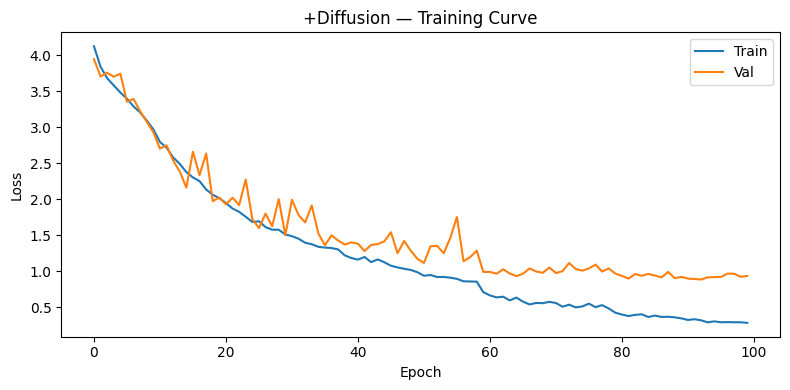

In [72]:
diff_model = BaselineCNN(num_classes=num_classes)

diff_model, df_train_l, df_val_l, df_val_acc = train_classifier(
    diff_model,
    diff_train_loader,
    diff_val_loader,
    run_name="+Diffusion",
    save_path=os.path.join(BASE_DIR, "saved_models", "baseline_diffusion.pth"),
)

plot_losses(df_train_l, df_val_l, title="+Diffusion — Training Curve")

In [73]:
load_checkpoint(os.path.join(BASE_DIR, "saved_models", "baseline_diffusion.pth"), diff_model)
diff_metrics = evaluate_classifier(diff_model, test_loader, label_to_idx, idx_to_label)
print(f"+Diffusion|  Accuracy: {diff_metrics['accuracy']:.4f}"
      f"  Macro F1: {diff_metrics['macro_f1']:.4f}")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\baseline_diffusion.pth
+Diffusion|  Accuracy: 0.7818  Macro F1: 0.7798


## Results Summary

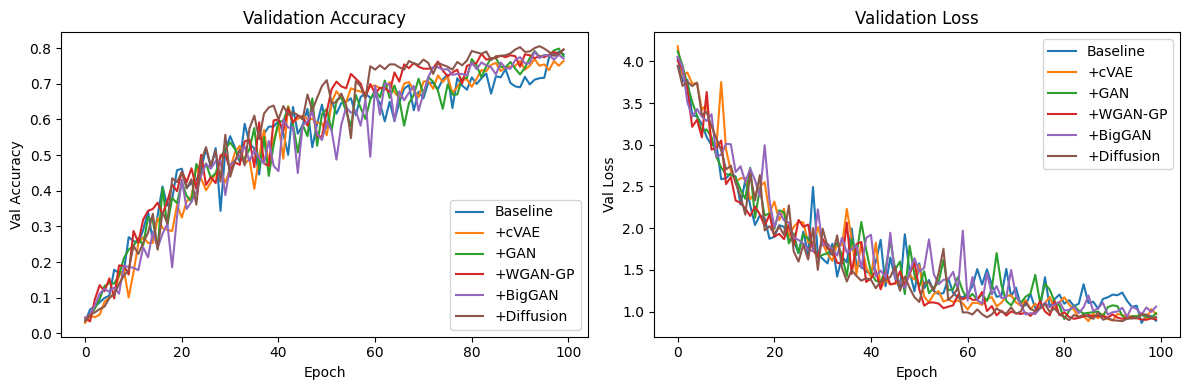

In [74]:
# ── Training curve overlay ─────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(bl_val_acc, label="Baseline")
plt.plot(cv_val_acc, label="+cVAE")
plt.plot(gn_val_acc, label="+GAN")
plt.plot(wg_val_acc, label="+WGAN-GP")
plt.plot(bg_val_acc, label="+BigGAN")
plt.plot(df_val_acc, label="+Diffusion")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.title("Validation Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(bl_val_l, label="Baseline")
plt.plot(cv_val_l, label="+cVAE")
plt.plot(gn_val_l, label="+GAN")
plt.plot(wg_val_l, label="+WGAN-GP")
plt.plot(bg_val_l, label="+BigGAN")
plt.plot(df_val_l, label="+Diffusion")
plt.xlabel("Epoch"); plt.ylabel("Val Loss"); plt.title("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
# ── Summary table ──────────────────────────────────────────────────────────
results = {
    "Baseline":    baseline_metrics,
    "+cVAE":       cvae_metrics,
    "+GAN":        gan_metrics,
    "+WGAN-GP":    wgan_gp_metrics,
    "+BigGAN":     biggan_metrics,
    "+Diffusion":  diff_metrics,
}

print(f"{'Model':<12} {'Top-1 Acc':>10} {'Macro F1':>10}")
print("-" * 34)
for name, m in results.items():
    print(f"{name:<12} {m['accuracy']:>10.4f} {m['macro_f1']:>10.4f}")

Model         Top-1 Acc   Macro F1
----------------------------------
Baseline         0.7594     0.7578
+cVAE            0.7535     0.7518
+GAN             0.7677     0.7684
+WGAN-GP         0.7606     0.7567
+BigGAN          0.7465     0.7425
+Diffusion       0.7818     0.7798


In [76]:
# ── Per-class accuracy comparison ─────────────────────────────────────────
# Find classes where augmentation helped most
bl_pc  = baseline_metrics["per_class_acc"]
cv_pc  = cvae_metrics["per_class_acc"]
gn_pc  = gan_metrics["per_class_acc"]
wg_pc  = wgan_gp_metrics["per_class_acc"]
bg_pc  = biggan_metrics["per_class_acc"]
df_pc  = diff_metrics["per_class_acc"]

deltas = {
    cls: {
        "cvae_delta":      cv_pc.get(cls, 0) - bl_pc.get(cls, 0),
        "gan_delta":       gn_pc.get(cls, 0) - bl_pc.get(cls, 0),
        "wgan_gp_delta":   wg_pc.get(cls, 0) - bl_pc.get(cls, 0),
        "biggan_delta":    bg_pc.get(cls, 0) - bl_pc.get(cls, 0),
        "diffusion_delta": df_pc.get(cls, 0) - bl_pc.get(cls, 0),
    }
    for cls in bl_pc
}

for key, label in [
    ("cvae_delta",      "cVAE"),
    ("gan_delta",       "GAN"),
    ("wgan_gp_delta",   "WGAN-GP"),
    ("biggan_delta",    "BigGAN"),
    ("diffusion_delta", "Diffusion"),
]:
    top = sorted(deltas.items(), key=lambda x: x[1][key], reverse=True)[:10]
    print(f"\nTop-10 classes most improved by {label}:")
    for cls, d in top:
        print(f"  {cls:<35} Δ={d[key]:+.4f}  (baseline={bl_pc[cls]:.4f})")


Top-10 classes most improved by cVAE:
  SLEEPY ORANGE                       Δ=+0.4286  (baseline=0.5000)
  CLEOPATRA                           Δ=+0.4167  (baseline=0.2500)
  PINE WHITE                          Δ=+0.2727  (baseline=0.5455)
  GREAT EGGFLY                        Δ=+0.2000  (baseline=0.5000)
  LARGE MARBLE                        Δ=+0.1818  (baseline=0.1818)
  IPHICLUS SISTER                     Δ=+0.1667  (baseline=0.5833)
  BLUE MORPHO                         Δ=+0.1111  (baseline=0.5556)
  AMERICAN SNOOT                      Δ=+0.1000  (baseline=0.4000)
  CRIMSON PATCH                       Δ=+0.1000  (baseline=0.9000)
  METALMARK                           Δ=+0.1000  (baseline=0.5000)

Top-10 classes most improved by GAN:
  PINE WHITE                          Δ=+0.2727  (baseline=0.5455)
  CLODIUS PARNASSIAN                  Δ=+0.2727  (baseline=0.3636)
  JULIA                               Δ=+0.2727  (baseline=0.6364)
  METALMARK                           Δ=+0.2000  (ba